# Module 3: EDA & Preprocessing — Indicators of Heart Disease (2022)

This notebook downloads the **2022 update** of the *Personal Key Indicators of Heart Disease* dataset from Kaggle (source: `kamilpytlak/personal-key-indicators-of-heart-disease`), explores it through Exploratory Data Analysis (EDA), and prepares it for modeling through Preprocessing. The notebook is organized into three main sections: **1. Download Data**, **2. EDA**, and **3. Preprocessing**.

## 1. Download Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('Kaggle credentials ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Kaggle credentials ready.


In [ ]:
!pip install -q --upgrade kaggle
!mkdir -p /content/kaggle_data
!kaggle datasets download -d kamilpytlak/personal-key-indicators-of-heart-disease -p /content/kaggle_data --unzip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 8.8 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease
License(s): CC0-1.0
100% 21.4M/21.4M [00:00<00:00, 121MB/s]



In [ ]:
import glob
for f in sorted(glob.glob('/content/kaggle_data/**/*', recursive=True)):
    print(f)

/content/kaggle_data/2020
/content/kaggle_data/2020/heart_2020_cleaned.csv
/content/kaggle_data/2022
/content/kaggle_data/2022/heart_2022_no_nans.csv
/content/kaggle_data/2022/heart_2022_with_nans.csv


In [ ]:
import pandas as pd

data_path = '/content/kaggle_data/2022/heart_2022_with_nans.csv'
df = pd.read_csv(data_path)
print('Loaded file:', data_path)
print('Shape:', df.shape)
df.head()

Loaded file: /content/kaggle_data/2022/heart_2022_with_nans.csv
Shape: (445132, 40)


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,NaN,No,...,NaN,NaN,NaN,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No
1,Alabama,Female,Excellent,0.0,0.0,NaN,No,6.0,NaN,No,...,1.60,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,NaN,No,...,1.57,63.50,25.61,No,No,No,No,NaN,No,Yes
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,NaN,No,...,1.65,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,NaN,No,...,1.57,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


**Result:** The dataset was downloaded directly from Kaggle using the Kaggle API (authenticated with `kaggle.json`, which was read from Google Drive but not re-saved there) and unzipped into the local Colab runtime storage at `/content/kaggle_data` — no data was written back to Drive. The archive contains three files: `2020/heart_2020_cleaned.csv` (legacy 2020 survey), `2022/heart_2022_no_nans.csv` (2022 survey, already cleaned), and `2022/heart_2022_with_nans.csv` (2022 survey, raw with missing values). We load **`heart_2022_with_nans.csv`** on purpose, since it lets us demonstrate a realistic EDA and preprocessing workflow that includes handling missing values, rather than starting from an already-cleaned file. The loaded dataframe has **445,132 rows and 40 columns**, matching the official 2022 BRFSS update of this dataset.

## 2. Exploratory Data Analysis (EDA)

In [ ]:
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])
print()
print('Data types:')
print(df.dtypes.value_counts())
print()
df.info()

Number of rows: 445132
Number of columns: 40

Data types:
object     34
float64     6
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443

**Result:** The dataset has **445,132 rows and 40 columns**, made up of **34 categorical (`object`) columns** (e.g. `State`, `Sex`, `GeneralHealth`, most of the Yes/No health-history flags such as `HadHeartAttack`, `HadDiabetes`, `HadStroke`) and **6 numeric (`float64`) columns** (`PhysicalHealthDays`, `MentalHealthDays`, `SleepHours`, `HeightInMeters`, `WeightInKilograms`, `BMI`). Every column has some missing values — the `Non-Null Count` for each column is consistently below 445,132 — which confirms this is the raw survey file and that missing-value handling will be a necessary preprocessing step. The dataframe uses about 135.8+ MB of memory in its current (unoptimized) form.

In [ ]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print('Number of columns with missing values:', len(missing_summary))
print(missing_summary.to_string())

Number of columns with missing values: 38
                           missing_count  missing_pct
TetanusLast10Tdap                  82516        18.54
PneumoVaxEver                      77040        17.31
HIVTesting                         66127        14.86
ChestScan                          56046        12.59
CovidPos                           50764        11.40
HighRiskLastYear                   50623        11.37
BMI                                48806        10.96
FluVaxLast12                       47121        10.59
AlcoholDrinkers                    46574        10.46
WeightInKilograms                  42078         9.45
ECigaretteUsage                    35660         8.01
SmokerStatus                       35462         7.97
HeightInMeters                     28652         6.44
DifficultyErrands                  25656         5.76
DifficultyConcentrating            24240         5.45
DifficultyWalking                  24012         5.39
DifficultyDressingBathing          23915

**Result:** **38 of the 40 columns** contain at least one missing value — only `State` and `Sex` are fully populated. The most affected columns are vaccination/screening-history fields that many respondents simply skip or don't know: `TetanusLast10Tdap` (18.54%), `PneumoVaxEver` (17.31%), `HIVTesting` (14.86%), `ChestScan` (12.59%), `CovidPos` (11.40%), and `HighRiskLastYear` (11.37%). The core numeric health metrics have moderate missingness (`BMI` 10.96%, `WeightInKilograms` 9.45%, `HeightInMeters` 6.44%), while the disease-history Yes/No flags (`HadHeartAttack`, `HadStroke`, `HadDiabetes`, etc.) and core demographics are the most complete, at well under 1% missing. This pattern is typical of self-reported survey data: harder-to-recall or less commonly asked questions have more gaps. It tells us we can safely impute the low-missingness columns with simple statistics, while columns above ~10% missing deserve a bit more care during preprocessing.

In [ ]:
numeric_cols = ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'HeightInMeters', 'WeightInKilograms', 'BMI']
df[numeric_cols].describe().round(2)

,PhysicalHealthDays,MentalHealthDays,SleepHours,HeightInMeters,WeightInKilograms,BMI
count,434205.00,436065.00,439679.00,416480.00,403054.00,396326.00
mean,4.35,4.38,7.02,1.70,83.07,28.53
std,8.69,8.39,1.50,0.11,21.45,6.55
min,0.00,0.00,1.00,0.91,22.68,12.02
25%,0.00,0.00,6.00,1.63,68.04,24.13
50%,0.00,0.00,7.00,1.70,80.74,27.44
75%,3.00,5.00,8.00,1.78,95.25,31.75
max,30.00,30.00,24.00,2.41,292.57,99.64


**Result:** The numeric columns show sensible but skewed distributions typical of health survey data. `PhysicalHealthDays` and `MentalHealthDays` (days out of the past 30 with poor health) both have a median of 0–4 but a mean around 4.3–4.4, indicating a right-skewed distribution where most people report very few bad days while a smaller group reports many (up to the maximum of 30). `SleepHours` is centered close to the recommended 7–8 hours (mean 7.02, IQR 6–8), though the max of 24 is very likely a data-entry outlier. `HeightInMeters` (mean 1.70m) and `WeightInKilograms` (mean 83.07kg) look reasonable, but `BMI` has a very wide range (12.02 to 99.64) with a mean of 28.53 — already in the "overweight" clinical range — and the extreme maximum values suggest a handful of outliers that should be kept in mind (though not necessarily removed) during preprocessing.

HadHeartAttack value counts:
HadHeartAttack
No     416959
Yes     25108
NaN      3065
Name: count, dtype: int64

HadHeartAttack percentages:
HadHeartAttack
No     93.67
Yes     5.64
NaN     0.69
Name: proportion, dtype: float64


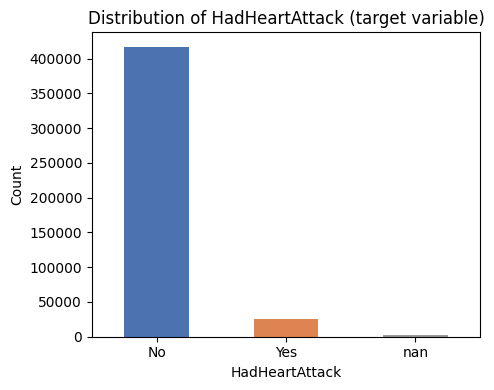

In [ ]:
import matplotlib.pyplot as plt

target_counts = df['HadHeartAttack'].value_counts(dropna=False)
target_pct = df['HadHeartAttack'].value_counts(normalize=True, dropna=False).mul(100).round(2)
print('HadHeartAttack value counts:')
print(target_counts)
print()
print('HadHeartAttack percentages:')
print(target_pct)

fig, ax = plt.subplots(figsize=(5, 4))
target_counts.plot(kind='bar', color=['#4C72B0', '#DD8452', '#999999'], ax=ax)
ax.set_title('Distribution of HadHeartAttack (target variable)')
ax.set_xlabel('HadHeartAttack')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Result:** The target variable `HadHeartAttack` is heavily imbalanced: **93.67% (416,959)** respondents answered "No", only **5.64% (25,108)** answered "Yes", and a small **0.69% (3,065)** are missing. This roughly 17:1 ratio between the majority and minority classes is expected for a real-world disease-prevalence variable, but it has an important consequence for modeling later: metrics like plain accuracy would be misleading (a model that always predicts "No" would already score ~94%), so techniques such as class weighting, resampling, or threshold tuning — combined with metrics like recall, F1, or ROC-AUC — will matter more than raw accuracy. The missing target rows will be dropped in preprocessing, since we cannot train or evaluate on a label we don't have.

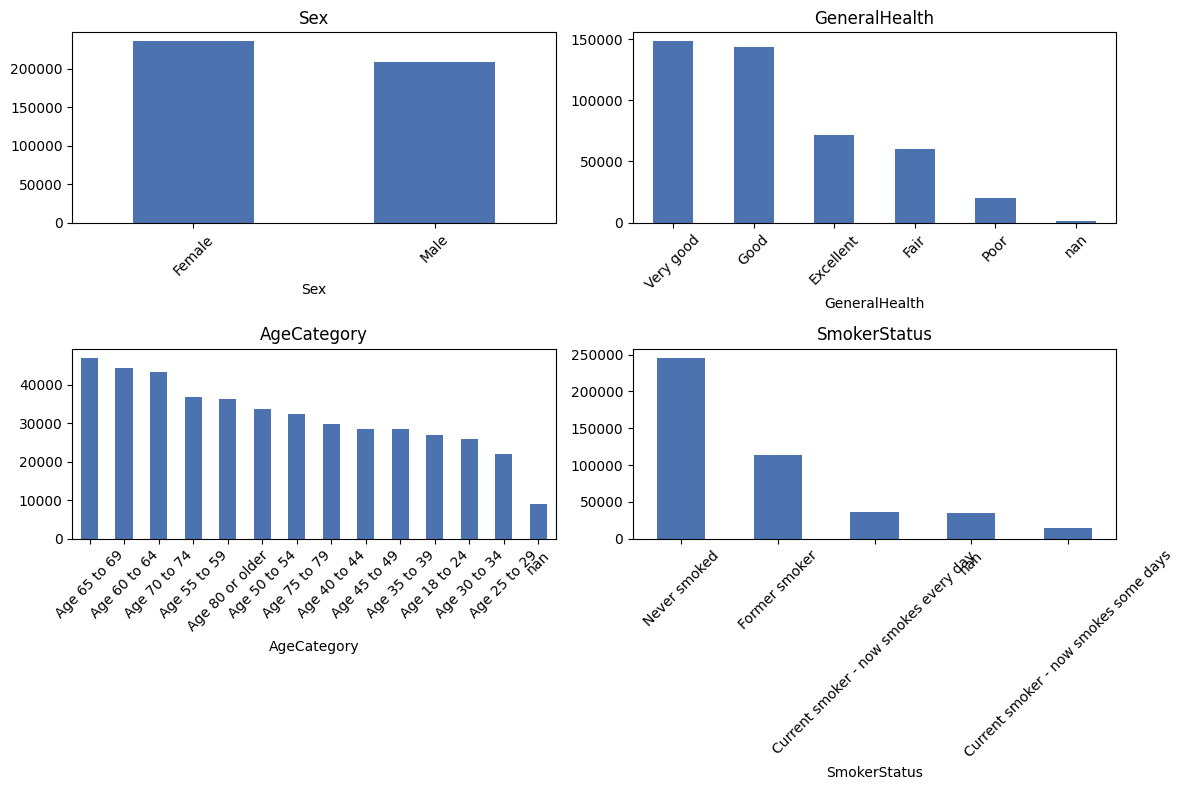

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cat_cols_to_plot = ['Sex', 'GeneralHealth', 'AgeCategory', 'SmokerStatus']
for ax, col in zip(axes.flat, cat_cols_to_plot):
    df[col].value_counts(dropna=False).plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Result:** The survey population is fairly balanced by sex (roughly 52% Female / 48% Male) and skews toward older respondents — the largest single age bracket is "65 to 69", and counts generally decline for younger brackets, which is typical of BRFSS telephone-survey data. Self-reported general health is mostly positive: "Very good" and "Good" together account for the large majority of responses, with only a small share reporting "Poor" health. For smoking, the majority of respondents (`Never smoked`) have never smoked, roughly a quarter are former smokers, and current smokers (daily or occasional) make up a relatively small minority. These distributions confirm the dataset represents a broad, mostly older, general-population sample rather than a clinically pre-selected group, which is appropriate for a population health-risk study.

                    PhysicalHealthDays  MentalHealthDays  SleepHours  \
PhysicalHealthDays                1.00              0.32       -0.06   
MentalHealthDays                  0.32              1.00       -0.13   
SleepHours                       -0.06             -0.13        1.00   
HeightInMeters                   -0.05             -0.05       -0.01   
WeightInKilograms                 0.07              0.04       -0.05   
BMI                               0.11              0.08       -0.05   

                    HeightInMeters  WeightInKilograms   BMI  
PhysicalHealthDays           -0.05               0.07  0.11  
MentalHealthDays             -0.05               0.04  0.08  
SleepHours                   -0.01              -0.05 -0.05  
HeightInMeters                1.00               0.47 -0.03  
WeightInKilograms             0.47               1.00  0.86  
BMI                          -0.03               0.86  1.00  


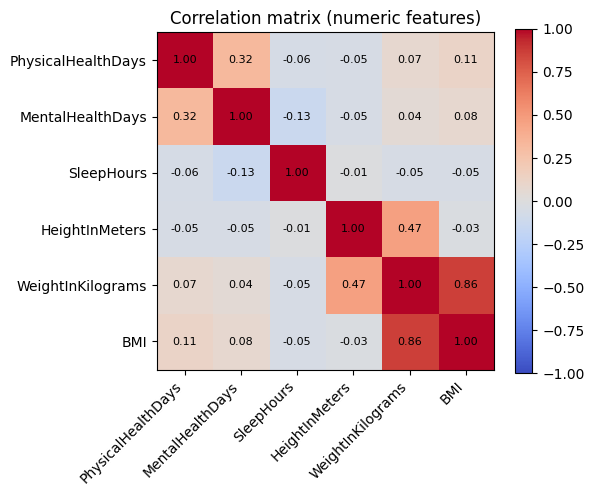

In [ ]:
corr = df[numeric_cols].corr()
print(corr.round(2))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', color='black', fontsize=8)
ax.set_title('Correlation matrix (numeric features)')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

**Result:** The correlation matrix shows that WeightInKilograms and BMI are strongly correlated (0.86), which is expected since BMI is mathematically derived from weight (and height). HeightInMeters and WeightInKilograms show a moderate positive correlation (0.47), while HeightInMeters and BMI are nearly uncorrelated (-0.03), confirming that BMI successfully normalizes out the effect of height. PhysicalHealthDays and MentalHealthDays are moderately correlated (0.32), suggesting that people who report more days of poor physical health also tend to report more days of poor mental health. SleepHours is weakly (and mostly negatively) correlated with all other numeric features, indicating it behaves largely independently. Overall, aside from the expected Weight-BMI relationship, no pair of features is so highly correlated that multicollinearity is a major concern for this dataset.

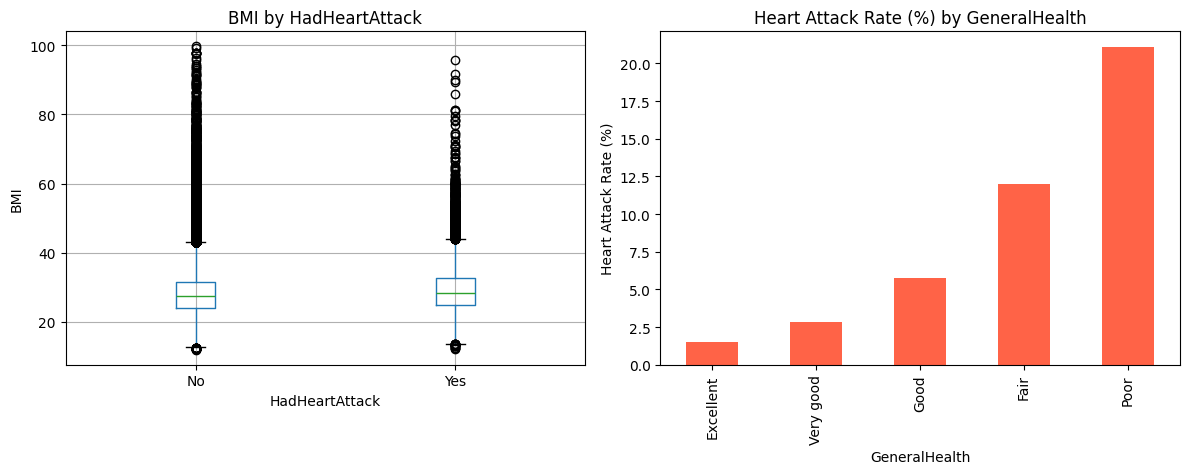

GeneralHealth
Excellent     1.53
Very good     2.84
Good          5.78
Fair         11.99
Poor         21.08
Name: HadHeartAttack, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='BMI', by='HadHeartAttack', ax=axes[0])
axes[0].set_title('BMI by HadHeartAttack')
axes[0].set_xlabel('HadHeartAttack')
axes[0].set_ylabel('BMI')
health_order = ['Excellent', 'Very good', 'Good', 'Fair', 'Poor']
rate = df.groupby('GeneralHealth')['HadHeartAttack'].apply(lambda x: (x == 'Yes').mean() * 100)
rate = rate.reindex(health_order)
rate.plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Heart Attack Rate (%) by GeneralHealth')
axes[1].set_xlabel('GeneralHealth')
axes[1].set_ylabel('Heart Attack Rate (%)')
plt.suptitle('')
plt.tight_layout()
plt.show()
print(rate.round(2))

**Result:** The boxplot shows that BMI distributions are very similar between people who did and did not have a heart attack (both medians around 27-28), so BMI alone is a weak discriminator for this target. In contrast, the bar chart of heart attack rate by self-reported GeneralHealth shows a clear, strong, monotonic relationship: the rate rises from 1.53% for 'Excellent' health to 2.84% ('Very good'), 5.78% ('Good'), 11.99% ('Fair'), and 21.08% for 'Poor' health. This indicates GeneralHealth is a much more informative predictor of heart attack risk than BMI, and highlights the value of including categorical self-reported health features in the model alongside numeric measurements.

## 3. Preprocessing

This section prepares the raw data for machine learning: cleaning the target variable, handling missing values, encoding categorical features, and scaling numeric features.

In [ ]:
df_clean = df.copy()
before_rows = len(df_clean)
df_clean = df_clean.dropna(subset=['HadHeartAttack']).reset_index(drop=True)
after_rows = len(df_clean)
print(f'Rows before dropping missing target: {before_rows}')
print(f'Rows after dropping missing target: {after_rows}')
print(f'Rows dropped: {before_rows - after_rows}')
df_clean['HadHeartAttack'] = df_clean['HadHeartAttack'].map({'Yes': 1, 'No': 0})
print(df_clean['HadHeartAttack'].value_counts())

Rows before dropping missing target: 445132
Rows after dropping missing target: 442067
Rows dropped: 3065
HadHeartAttack
0    416959
1     25108
Name: count, dtype: int64


**Result:** The 3,065 rows (0.69%) with a missing target value were removed, since imputing a label is not appropriate for a classification target — this leaves 442,067 usable rows. The target was also encoded as a binary integer (Yes=1, No=0) for use in ML models. The resulting class distribution is highly imbalanced: 416,959 negatives (94.32%) vs. 25,108 positives (5.68%), which is important to account for later (e.g. with class weighting or resampling) when training a classifier.

In [ ]:
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())
categorical_cols = [c for c in df_clean.columns if c not in numeric_cols and c != 'HadHeartAttack']
mode_values = df_clean[categorical_cols].mode().iloc[0]
df_clean[categorical_cols] = df_clean[categorical_cols].fillna(mode_values)
print('Number of numeric columns imputed (median):', len(numeric_cols))
print('Number of categorical columns imputed (mode):', len(categorical_cols))
print('Total missing values remaining:', df_clean.isna().sum().sum())

Number of numeric columns imputed (median): 6
Number of categorical columns imputed (mode): 33
Total missing values remaining: 0


**Result:** All 6 numeric columns were imputed using the column median (robust to outliers), and all 33 categorical columns were imputed using the column mode (most frequent category). After imputation, the dataset has 0 remaining missing values across all 442,067 rows, so the data is now fully complete and ready for encoding.

In [ ]:
tegorical columns, 22 are binary (mostly Yes/No health-history flags, e.g. HadStroke, HadAngina, AlcoholDrinkers) and 11 have 3–54 categories. The multi-category columns range from CovidPos (3 categories) up to State (54 categories, i.e. all US states/territories in the survey). Binary columns will be label-encoded to 0/1, and the 11 multi-category columns will be one-hot encoded, since they have no inherent order (except AgeCategory and GeneralHealth, which are ordinal but still small enough to one-hot encode safely).

In [ ]:
binary_cols = [c for c in categorical_cols if df_clean[c].nunique() == 2]
multi_cols = [c for c in categorical_cols if df_clean[c].nunique() > 2]
print('Number of binary categorical columns:', len(binary_cols))
print('Number of multi-category categorical columns:', len(multi_cols))
print(df_clean[categorical_cols].nunique().sort_values().to_string())

Number of binary categorical columns: 22
Number of multi-category categorical columns: 11
Sex                           2
HadStroke                     2
HadAngina                     2
PhysicalActivities            2
HadDepressiveDisorder         2
HadCOPD                       2
HadSkinCancer                 2
HadAsthma                     2
HadKidneyDisease              2
HadArthritis                  2
DeafOrHardOfHearing           2
DifficultyErrands             2
DifficultyDressingBathing     2
DifficultyWalking             2
DifficultyConcentrating       2
BlindOrVisionDifficulty       2
HighRiskLastYear              2
FluVaxLast12                  2
PneumoVaxEver                 2
HIVTesting                    2
AlcoholDrinkers               2
ChestScan                     2
CovidPos                      3
LastCheckupTime               4
ECigaretteUsage               4
TetanusLast10Tdap             4
HadDiabetes                   4
SmokerStatus                  4
RemovedTeeth  

**Result:** Of the 33 categorical columns, 22 are binary (mostly Yes/No health-history flags, e.g. HadStroke, HadAngina, AlcoholDrinkers) and 11 have 3–54 categories. The multi-category columns range from CovidPos (3 categories) up to State (54 categories, i.e. all US states/territories in the survey). Binary columns will be label-encoded to 0/1, and the 11 multi-category columns will be one-hot encoded, since they have no inherent order (except AgeCategory and GeneralHealth, which are ordinal but still small enough to one-hot encode safely).

In [ ]:
df_clean[binary_cols] = df_clean[binary_cols].apply(lambda col: pd.factorize(col)[0])
df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=False)
print('Shape before one-hot encoding: (442067, 40)')
print('Shape after one-hot encoding:', df_clean.shape)
print('Number of columns added by one-hot encoding:', df_clean.shape[1] - 40)

Shape before one-hot encoding: (442067, 40)
Shape after one-hot encoding: (442067, 133)
Number of columns added by one-hot encoding: 93


**Result:** The 22 binary categorical columns were label-encoded to integers 0/1, and the 11 multi-category columns were one-hot encoded, expanding the dataset from 40 to 133 columns (93 new dummy columns). This is a large but manageable increase, driven mostly by the State column (54 categories). One-hot encoding avoids implying a false numeric order between unrelated categories (e.g. between different states or races), which is important for most ML algorithms.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])
print(df_clean[numeric_cols].describe().round(2).to_string())

       PhysicalHealthDays  MentalHealthDays  SleepHours  HeightInMeters  WeightInKilograms        BMI
count           442067.00         442067.00   442067.00       442067.00          442067.00  442067.00
mean                -0.00             -0.00        0.00            0.00              -0.00      -0.00
std                  1.00              1.00        1.00            1.00               1.00       1.00
min                 -0.49             -0.52       -4.05           -7.64              -2.95      -2.65
25%                 -0.49             -0.52       -0.69           -0.70              -0.73      -0.65
50%                 -0.49             -0.52       -0.02           -0.02              -0.10      -0.16
75%                 -0.14             -0.03        0.66            0.75               0.43       0.42
max                  3.00              3.09       11.41            6.82              10.27      11.50


**Result:** The 6 numeric columns were standardized using StandardScaler, so each now has mean ≈ 0 and standard deviation = 1. This puts all numeric features on a comparable scale, which is important for distance-based or gradient-based ML algorithms (e.g. logistic regression, KNN, SVM, neural networks) that would otherwise be dominated by features with larger raw ranges (like WeightInKilograms vs. SleepHours). Note the wide max values for some scaled features (e.g. HeightInMeters max = 6.82, PhysicalHealthDays max = 3.00), reflecting the outliers seen earlier in the EDA step — these are expected and not an error.

In [ ]:
print('Final preprocessed dataset shape:', df_clean.shape)
print('Target distribution (%):')
print((df_clean['HadHeartAttack'].value_counts(normalize=True) * 100).round(2))
df_clean.head()

Final preprocessed dataset shape: (442067, 133)
Target distribution (%):
HadHeartAttack
0    94.32
1     5.68
Name: proportion, dtype: float64


,Sex,PhysicalHealthDays,MentalHealthDays,PhysicalActivities,SleepHours,HadHeartAttack,HadAngina,HadStroke,HadAsthma,HadSkinCancer,...,AgeCategory_Age 70 to 74,AgeCategory_Age 75 to 79,AgeCategory_Age 80 or older,"TetanusLast10Tdap_No, did not receive any tetanus shot in the past 10 years","TetanusLast10Tdap_Yes, received Tdap","TetanusLast10Tdap_Yes, received tetanus shot but not sure what type","TetanusLast10Tdap_Yes, received tetanus shot, but not Tdap",CovidPos_No,CovidPos_Tested positive using home test without a health professional,CovidPos_Yes
0,0,-0.491530,-0.515488,0,0.656772,0,0,0,0,0,...,False,False,True,False,False,True,False,True,False,False
1,0,-0.491530,-0.515488,0,-0.687687,0,0,0,0,1,...,False,False,True,True,False,False,False,True,False,False
2,0,-0.258523,-0.154541,1,-1.359916,0,0,0,0,1,...,False,False,False,True,False,False,False,False,False,True
3,0,-0.491530,-0.515488,1,-0.015457,0,0,0,1,0,...,False,False,False,True,False,False,False,True,False,False
4,0,-0.258523,-0.515488,1,1.329001,0,0,0,0,0,...,False,False,False,True,False,False,False,True,False,False


**Result:** The final preprocessed dataset has 442,067 rows and 133 columns, with 0 missing values, a binary numeric target (HadHeartAttack), all categorical features encoded (label encoding for binary columns, one-hot encoding for multi-category columns), and all 6 numeric features standardized. The target remains imbalanced (94.32% No vs. 5.68% Yes), which was preserved intentionally rather than artificially rebalanced, since resampling should typically be applied only to the training split (after a train/test split) to avoid data leakage. This dataset is now ready to be split into training and test sets and used to train a classification model for heart attack risk prediction.